# 02 - Audio Analysis

Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import stempeg
import soundfile as sf

Import directions 

In [ ]:
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from config import TRAIN_DIR

Load a track

In [3]:
track_files = sorted(TRAIN_DIR.glob("*.mp4"))

track_path = track_files[0]

print(track_path.name)

A Classic Education - NightOwl.stem.mp4


In [4]:
stems, sample_rate = stempeg.read_stems(str(track_path))

mixture = stems[0]
drums = stems[1]
bass = stems[2]
other = stems[3]
vocals = stems[4]

instrumental = drums + bass + other

In [5]:
print(f"Sample rate: {sample_rate} Hz")
print(f"Mixture shape: {mixture.shape}")
print(f"Vocals shape: {vocals.shape}")
print(f"Instrumental shape: {instrumental.shape}")

Sample rate: 44100 Hz
Mixture shape: (7551684, 2)
Vocals shape: (7551684, 2)
Instrumental shape: (7551684, 2)


Wave form

In [6]:
seconds = 10
samples = seconds * sample_rate

time = np.arange(samples) / sample_rate

Mixture

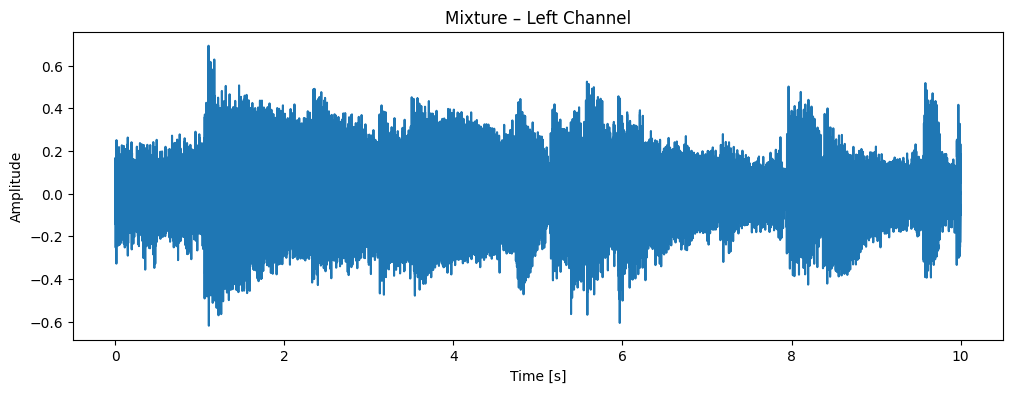

In [7]:
plt.figure(figsize=(12, 4))

plt.plot(time, mixture[:samples, 0])

plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Mixture – Left Channel")

plt.show()

Vocals

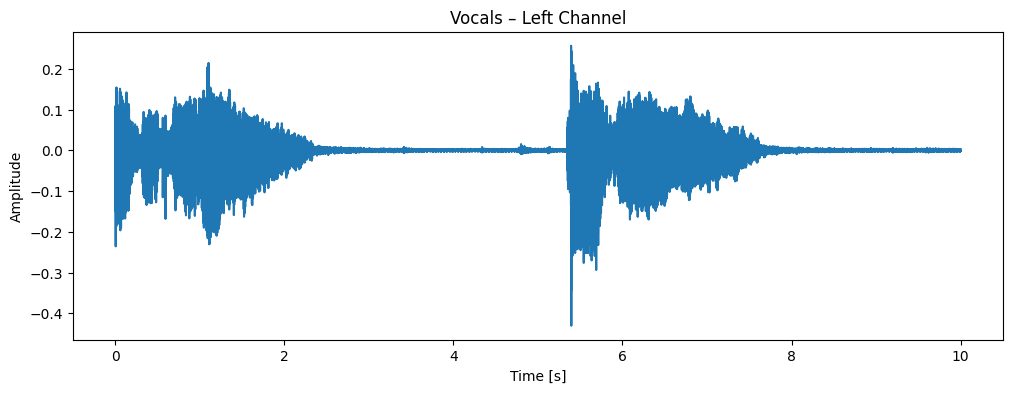

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(time, vocals[:samples, 0])

plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Vocals – Left Channel")

plt.show()

Instrumental

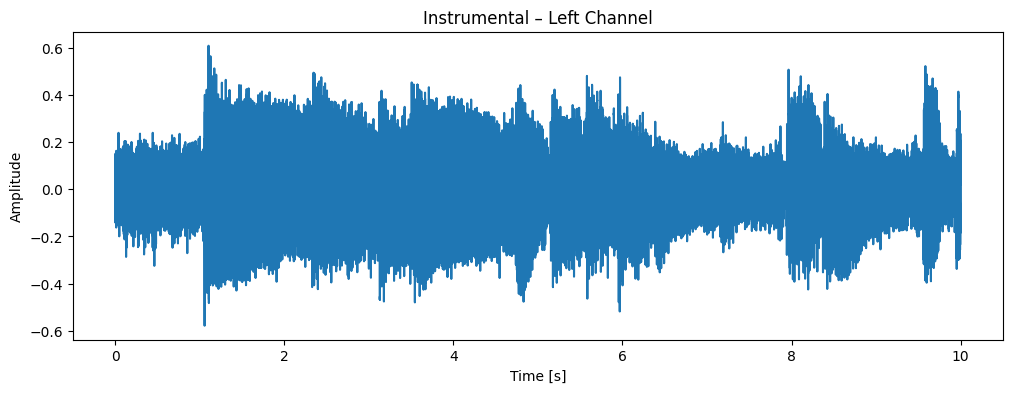

In [9]:
plt.figure(figsize=(12, 4))

plt.plot(time, instrumental[:samples, 0])

plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Instrumental – Left Channel")

plt.show()

## Conclusion

The analysis of a single MUSDB18 track shows how the complete mixture is composed of several separate sources.

The vocals and instrumental accompaniment have clearly different waveform characteristics, while the mixture contains information from both.

This confirms that MUSDB18 provides suitable ground-truth stems for supervised source separation.

The next step is to transform the audio signals into the frequency domain using STFT and analyze their spectrograms.